In [1]:
import os
import sys

sys.path.append(
    os.path.abspath(
        "../src"
    )
)

In [2]:
from data_loader import load_nuscenes

nusc = load_nuscenes()

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.113 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:
scene = nusc.scene[0]

sample = nusc.get(
    "sample",
    scene["first_sample_token"]
)

In [4]:
cam_token = sample["data"]["CAM_FRONT"]

lidar_token = sample["data"]["LIDAR_TOP"]


In [5]:
cam_data = nusc.get(
    "sample_data",
    cam_token
)

lidar_data = nusc.get(
    "sample_data",
    lidar_token
)

In [6]:
import cv2

img_path = os.path.join(
    nusc.dataroot,
    cam_data["filename"]
)

image = cv2.imread(
    img_path
)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

image.shape

(900, 1600, 3)

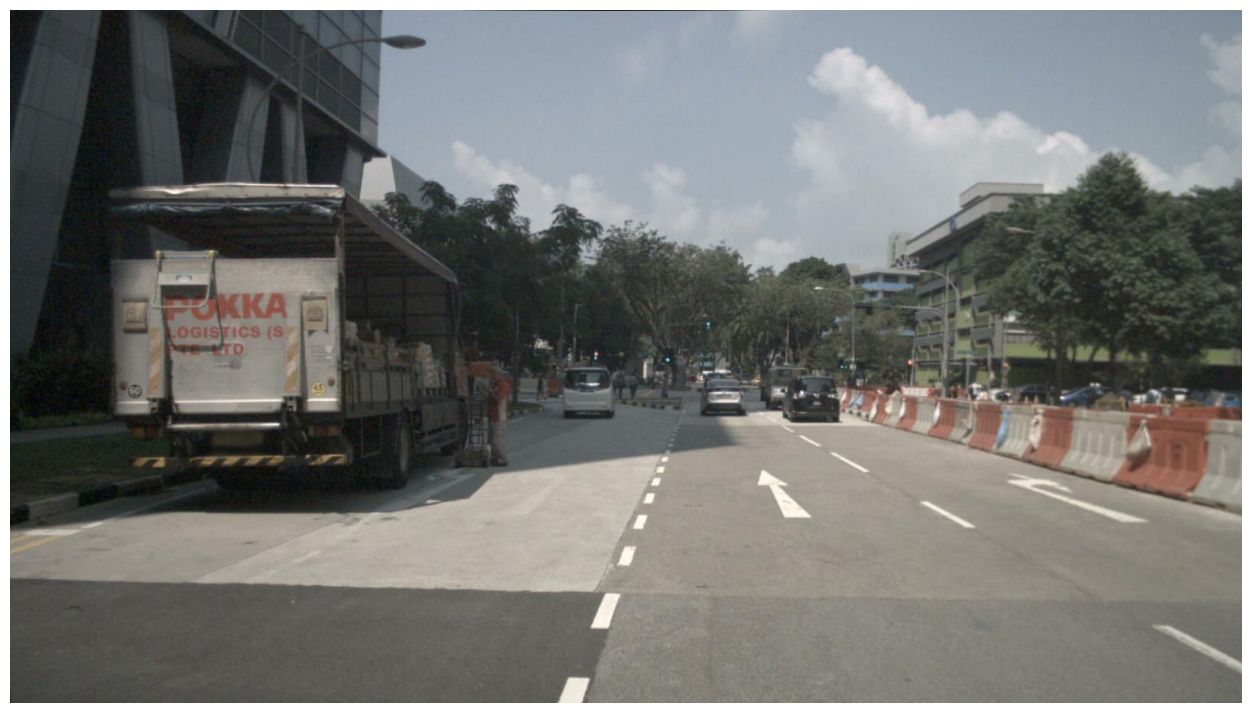

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

plt.imshow(image)

plt.axis("off")

plt.show()

In [8]:
from pipeline.fusion_pipeline import (
    run_fusion_pipeline
)

results = (
    run_fusion_pipeline(
        nusc,
        image,
        cam_data,
        lidar_data
    )
)

In [9]:
objects = results["objects"]

print(
    f"Detected Objects: {len(objects)}"
)

Detected Objects: 1


In [10]:
objects[0]

{'class': 'truck',
 'confidence': 0.7717981934547424,
 'mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(900, 1600), dtype=uint8),
 'u': array([     126.28,      127.17,       128.1,      128.71,      129.58,      128.84,      130.21,      135.32,      135.94,      136.82,      137.74,      138.32,      139.22,      138.66,      144.07,      144.94,      145.54,      146.42,      147.34,      148.79,       158.6,      165.71,      166.61,      168.15,
             126.51,      127.35,      128.44,       129.4,      130.45,      175.15,       176.1,       134.2,       177.9,      136.56,      137.44,      138.54,      139.41,      140.48,       184.7,       185.8,      144.16,      187.65,      146.63,      147.45,      148.53,      149.56,      150.52,      194.42,
              195.5,      154.14,      197.31,  

In [11]:
from fusion.validation import (
    create_fusion_summary
)

summary = (
    create_fusion_summary(
        objects
    )
)

summary

,class,confidence,distance,num_points,length,width,height
0,truck,0.772,7.15,196,5.8,7.75,1.03


In [12]:
from fusion.validation import (
    find_suspicious_objects
)

suspicious = (
    find_suspicious_objects(
        objects
    )
)

print(
    f"Suspicious Objects: {len(suspicious)}"
)

Suspicious Objects: 0


In [13]:
for obj in suspicious:

    print("\n----------------")

    print(
        "Class:",
        obj["class"]
    )

    print(
        "Distance:",
        round(
            obj["distance"],
            2
        )
    )

    print(
        "Points:",
        obj["num_points"]
    )

    print(
        "Dimensions:",
        obj["dimensions"]
    )

In [14]:
from visualization.fusion_debug_view import (
    visualize_object_fusion
)

In [15]:
for obj in suspicious:

    visualize_object_fusion(
        image,
        obj
    )

In [ ]:
from fusion.validation import (
    inspect_height_distribution
)

if len(suspicious) > 0:

    inspect_height_distribution(
        suspicious[0]
    )

else:

    print(
        "No suspicious objects found."
    )


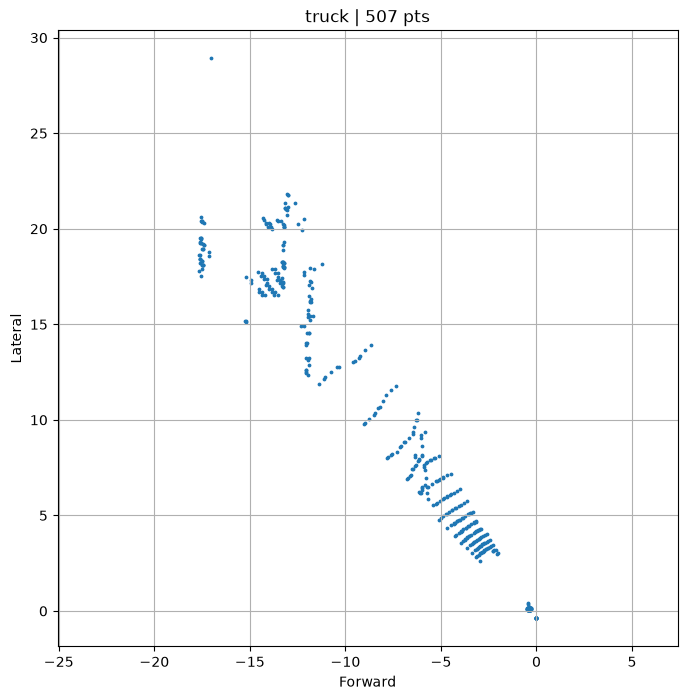

In [ ]:
from visualization.lidar_cluster_view import (
    visualize_lidar_cluster
)

visualize_lidar_cluster(
    objects[0]
)

In [ ]:
points = objects[0]["points_lidar"]

print(points.shape)

print(
    points[0].min(),
    points[0].max()
)

print(
    points[1].min(),
    points[1].max()
)

print(
    points[2].min(),
    points[2].max()
)

(3, 507)
-17.673584 -0.00044497117
-0.39349 28.910803
-1.7735857 4.9441285


In [ ]:
points = objects[0]["points_lidar"]

print("Shape:", points.shape)

print(
    "X:",
    points[0].min(),
    points[0].max()
)

print(
    "Y:",
    points[1].min(),
    points[1].max()
)

print(
    "Z:",
    points[2].min(),
    points[2].max()
)

Shape: (3, 507)
X: -17.673584 -0.00044497117
Y: -0.39349 28.910803
Z: -1.7735857 4.9441285


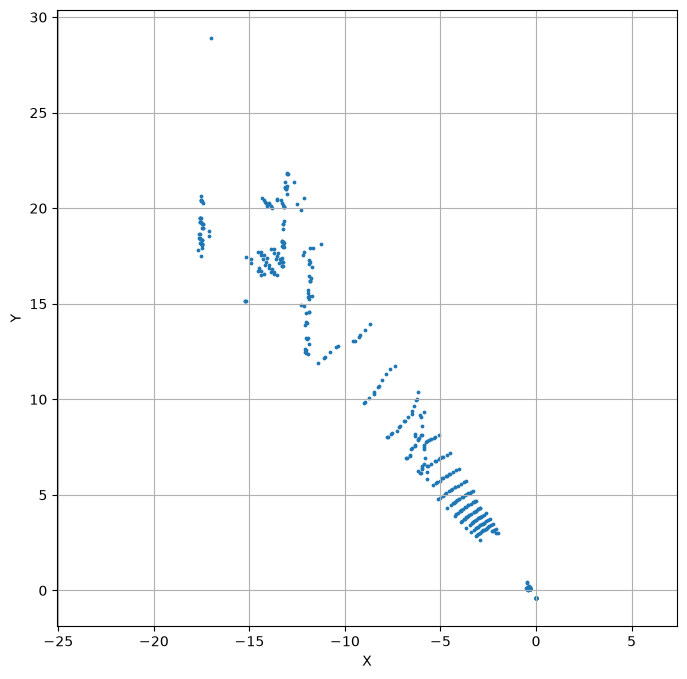

In [ ]:
import matplotlib.pyplot as plt

points = objects[0]["points_lidar"]

x = points[0]
y = points[1]

plt.figure(figsize=(8,8))

plt.scatter(
    x,
    y,
    s=3
)

plt.xlabel("X")
plt.ylabel("Y")

plt.axis("equal")
plt.grid()

plt.show()

In [17]:
print(len(objects))
print(len(suspicious))

1
0


In [18]:
inspect_height_distribution(
    objects[0]
)

{'min_z': -1.7735856771469116,
 'max_z': -0.7415039539337158,
 'height': 1.0320817232131958}

In [19]:
for obj in objects:

    print(obj["class"])

    print(
        inspect_height_distribution(
            obj
        )
    )

truck
{'min_z': -1.7735856771469116, 'max_z': -0.7415039539337158, 'height': 1.0320817232131958}


In [20]:
print(objects[0]["dimensions"])

{'length': 5.801918029785156, 'width': 7.747882843017578, 'height': 1.0320817232131958}


In [21]:
points = objects[0]["points_lidar"]

x = points[0]
y = points[1]
z = points[2]

print("Length:", x.max() - x.min())
print("Width :", y.max() - y.min())
print("Height:", z.max() - z.min())

print("\nCentroid:")
print(objects[0]["position"])

Length: 5.801918
Width : 7.747883
Height: 1.0320817

Centroid:
{'x': -4.381362438201904, 'y': 5.405948162078857, 'z': -1.6473236083984375}
